<a href="https://colab.research.google.com/github/shaikshahid07/FoDS/blob/main/CO2_AT3_ANALYTICAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


1. Online Food Delivery Data Analysis


Original Data
   Order_ID Restaurant  Delivery_Time  Price  Rating
0       101        A2B           30.0    250       5
1       102        KFC           45.0    450       4
2       103    Dominos            NaN    300       3
3       104        A2B           25.0   -100       5
4       105        KFC           60.0    500       2
5       105        KFC           60.0    500       2
6       106  Pizza Hut           35.0    350       4
7       107        A2B            NaN    280       5

Cleaned Data
   Order_ID Restaurant  Delivery_Time  Price  Rating
0       101        A2B           30.0    250       5
1       102        KFC           45.0    450       4
2       103    Dominos           42.5    300       3
3       104        A2B           25.0    100       5
4       105        KFC           60.0    500       2
6       106  Pizza Hut           35.0    350       4
7       107        A2B           42.5    280       5

Filtered Orders
   Order_ID Restaurant  Delivery_Time  Price  Rating
1

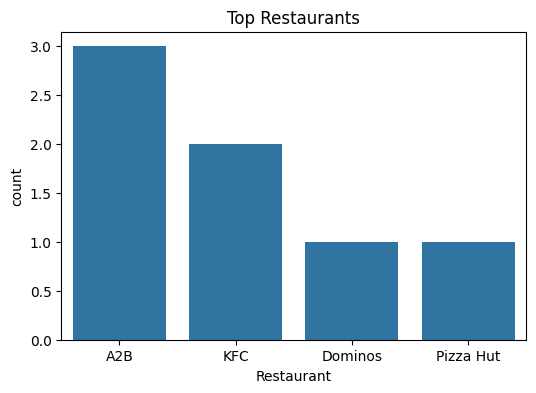

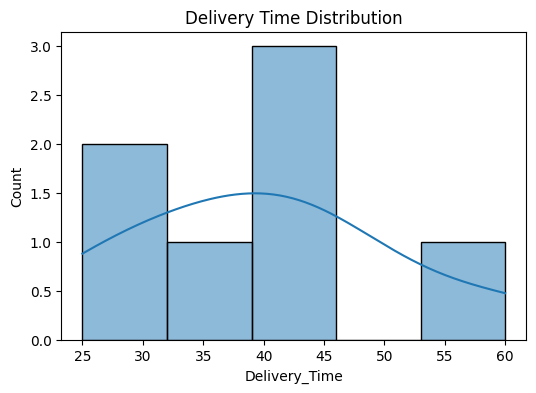

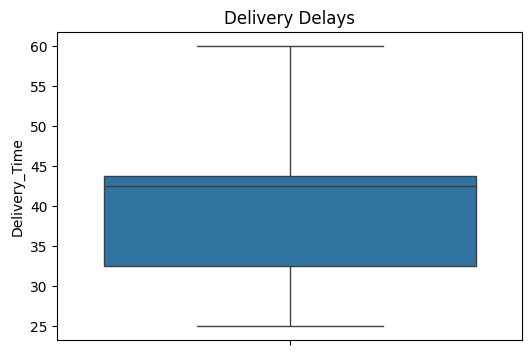

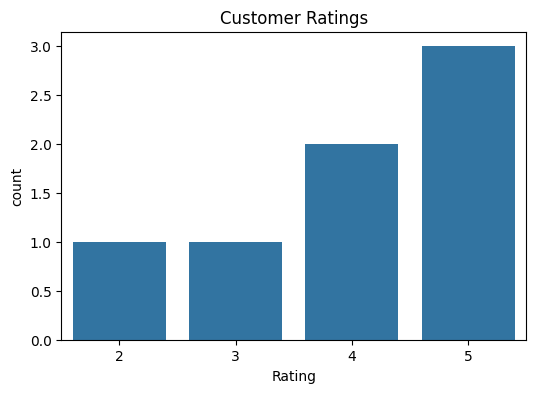

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "Order_ID": [101, 102, 103, 104, 105, 105, 106, 107],
    "Restaurant": ["A2B", "KFC", "Dominos", "A2B", "KFC", "KFC", "Pizza Hut", "A2B"],
    "Delivery_Time": [30, 45, None, 25, 60, 60, 35, None],
    "Price": [250, 450, 300, -100, 500, 500, 350, 280],
    "Rating": [5, 4, 3, 5, 2, 2, 4, 5]
}

df = pd.DataFrame(data)

print("Original Data")
print(df)

df["Delivery_Time"] = df["Delivery_Time"].fillna(df["Delivery_Time"].mean())
df["Price"] = df["Price"].apply(lambda x: abs(x))
df = df.drop_duplicates()

filtered = df[df["Delivery_Time"] > 30]

print("\nCleaned Data")
print(df)

print("\nFiltered Orders")
print(filtered)

plt.figure(figsize=(6,4))
sns.countplot(x="Restaurant", data=df)
plt.title("Top Restaurants")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df["Delivery_Time"], bins=5, kde=True)
plt.title("Delivery Time Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(y=df["Delivery_Time"])
plt.title("Delivery Delays")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Rating", data=df)
plt.title("Customer Ratings")
plt.show()

2. Bank Loan Approval Analysis

Original Data
  Customer  Gender Employment   Income  Loan_Amount  Credit_Score  \
0        A    Male   Salaried  50000.0       200000           720   
1        B  Female   Business  60000.0       250000           680   
2        C  Female   Salaried      NaN       180000           650   
3        D    Male   Business  80000.0       300000           780   
4        E    Male   Salaried  75000.0       220000           700   
5        F  Female   Business      NaN       270000           690   
6        G    Male   Salaried  90000.0       350000           800   

  Approval_Status  
0        Approved  
1        Rejected  
2        Rejected  
3        Approved  
4        Approved  
5        Rejected  
6        Approved  

Selected Columns
    Income  Loan_Amount  Credit_Score Approval_Status
0  50000.0       200000           720        Approved
1  60000.0       250000           680        Rejected
2      NaN       180000           650        Rejected
3  80000.0       300000           780  

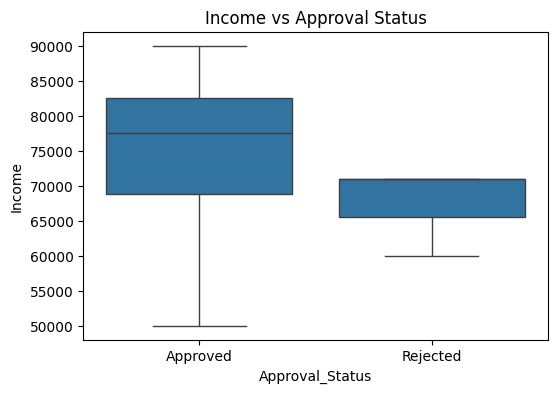

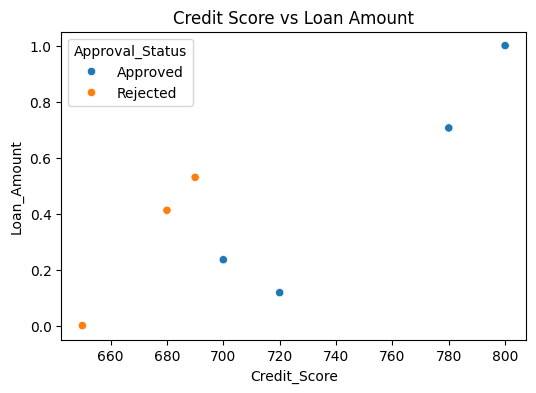

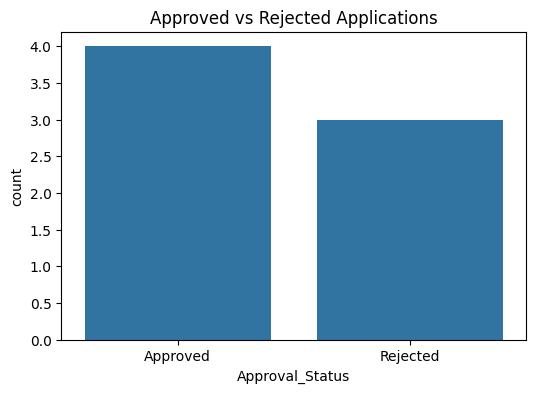

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

data = {
    "Customer": ["A", "B", "C", "D", "E", "F", "G"],
    "Gender": ["Male", "Female", "Female", "Male", "Male", "Female", "Male"],
    "Employment": ["Salaried", "Business", "Salaried", "Business", "Salaried", "Business", "Salaried"],
    "Income": [50000, 60000, None, 80000, 75000, None, 90000],
    "Loan_Amount": [200000, 250000, 180000, 300000, 220000, 270000, 350000],
    "Credit_Score": [720, 680, 650, 780, 700, 690, 800],
    "Approval_Status": ["Approved", "Rejected", "Rejected", "Approved", "Approved", "Rejected", "Approved"]
}

df = pd.DataFrame(data)

print("Original Data")
print(df)

selected = df[["Income", "Loan_Amount", "Credit_Score", "Approval_Status"]]
print("\nSelected Columns")
print(selected)

df["Income"] = df["Income"].fillna(df["Income"].mean())

le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["Employment"] = le.fit_transform(df["Employment"])

scaler = MinMaxScaler()
df["Loan_Amount"] = scaler.fit_transform(df[["Loan_Amount"]])

print("\nPreprocessed Data")
print(df)

plt.figure(figsize=(6,4))
sns.boxplot(x="Approval_Status", y="Income", data=df)
plt.title("Income vs Approval Status")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="Credit_Score", y="Loan_Amount", hue="Approval_Status", data=df)
plt.title("Credit Score vs Loan Amount")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Approval_Status", data=df)
plt.title("Approved vs Rejected Applications")
plt.show()


3. Smart Energy Consumption Monitoring

Original Data
         Date     Appliance  Power
0  2026-07-01            AC   12.5
1  2026-07-01           Fan    2.0
2  2026-07-01         Light    NaN
3  2026-07-01  Refrigerator    3.5
4  2026-07-02            AC   15.0
5  2026-07-02           Fan    2.5
6  2026-07-02         Light    1.2
7  2026-07-02  Refrigerator   50.0

Grouped Usage
         Date     Appliance      Power
0  2026-07-01            AC  12.500000
1  2026-07-01           Fan   2.000000
2  2026-07-01         Light  12.385714
3  2026-07-01  Refrigerator   3.500000
4  2026-07-02            AC  15.000000
5  2026-07-02           Fan   2.500000
6  2026-07-02         Light   1.200000

Total Power Consumption
         Date  Total_Power
0  2026-07-01    30.385714
1  2026-07-02    18.700000


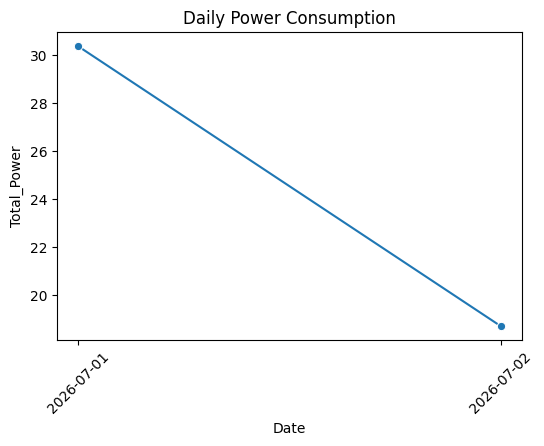

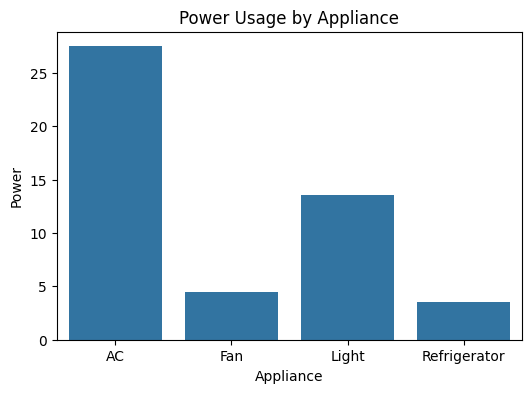

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "Date": ["2026-07-01", "2026-07-01", "2026-07-01", "2026-07-01",
             "2026-07-02", "2026-07-02", "2026-07-02", "2026-07-02"],
    "Appliance": ["AC", "Fan", "Light", "Refrigerator",
                  "AC", "Fan", "Light", "Refrigerator"],
    "Power": [12.5, 2.0, None, 3.5, 15.0, 2.5, 1.2, 50.0]
}

df = pd.DataFrame(data)

print("Original Data")
print(df)

df["Power"] = df["Power"].fillna(df["Power"].mean())
df = df[df["Power"] <= 20]

usage = df.groupby(["Date", "Appliance"])["Power"].sum().reset_index()
total = df.groupby("Date")["Power"].sum().reset_index(name="Total_Power")

print("\nGrouped Usage")
print(usage)

print("\nTotal Power Consumption")
print(total)

plt.figure(figsize=(6,4))
sns.lineplot(x="Date", y="Total_Power", data=total, marker="o")
plt.title("Daily Power Consumption")
plt.xticks(rotation=45)
plt.show()

appliance_usage = df.groupby("Appliance")["Power"].sum().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x="Appliance", y="Power", data=appliance_usage)
plt.title("Power Usage by Appliance")
plt.show()

4. Online Learning Platform Performance Analysis


Original Data
  Student  Quiz_Score  Completion  Login_Date
0       A        85.0          90  01-07-2026
1       B         NaN          75  02-07-2026
2       C        70.0          80  03-07-2026
3       D        95.0         100  04-07-2026
4       E        60.0          60  05-07-2026

Processed Data
  Student  Quiz_Score  Completion Login_Date Performance
3       D        95.0         100 2026-07-04        Good
0       A        85.0          90 2026-07-01        Good
1       B        77.5          75 2026-07-02        Good
2       C        70.0          80 2026-07-03     Average
4       E        60.0          60 2026-07-05     Average


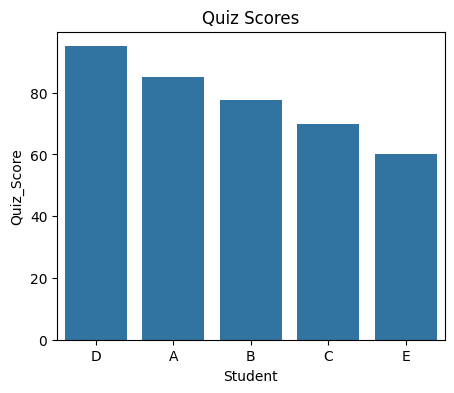

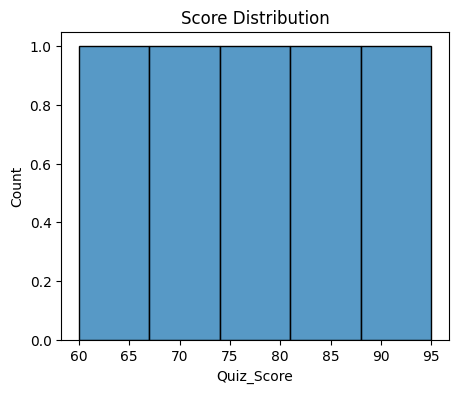

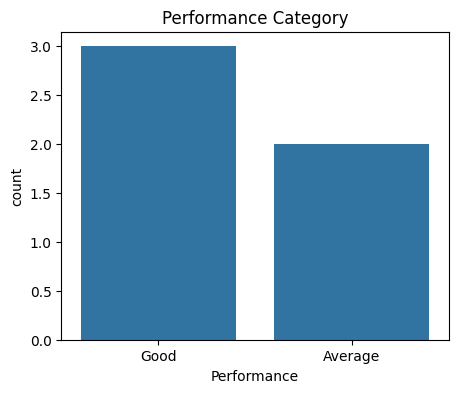

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "Student": ["A", "B", "C", "D", "E"],
    "Quiz_Score": [85, None, 70, 95, 60],
    "Completion": [90, 75, 80, 100, 60],
    "Login_Date": ["01-07-2026", "02-07-2026", "03-07-2026", "04-07-2026", "05-07-2026"]
}

df = pd.DataFrame(data)

print("Original Data")
print(df)

df["Quiz_Score"] = df["Quiz_Score"].fillna(df["Quiz_Score"].mean())
df["Login_Date"] = pd.to_datetime(df["Login_Date"], dayfirst=True)

df["Performance"] = ["Good" if x >= 75 else "Average" for x in df["Quiz_Score"]]

df = df.sort_values("Quiz_Score", ascending=False)

print("\nProcessed Data")
print(df)

plt.figure(figsize=(5,4))
sns.barplot(x="Student", y="Quiz_Score", data=df)
plt.title("Quiz Scores")
plt.show()

plt.figure(figsize=(5,4))
sns.histplot(df["Quiz_Score"], bins=5)
plt.title("Score Distribution")
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(x="Performance", data=df)
plt.title("Performance Category")
plt.show()

5. Public Transport Passenger Data Analysis


Original Data
  Route Stop  Time  Passengers
0    R1    A   8AM        50.0
1    R2    B   9AM         NaN
2    R1    C   8AM        70.0
3    R3    A  10AM        40.0
4    R2    B   9AM        60.0
5    R1    C   8AM        70.0

Passengers by Route
  Route  Passengers
0    R1       120.0
1    R2       118.0
2    R3        40.0

Passengers by Time
   Time  Passengers
0  10AM        40.0
1   8AM       120.0
2   9AM       118.0


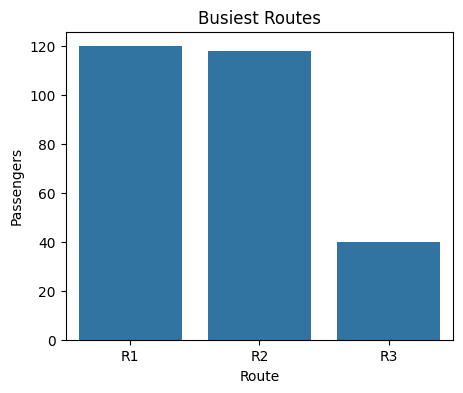

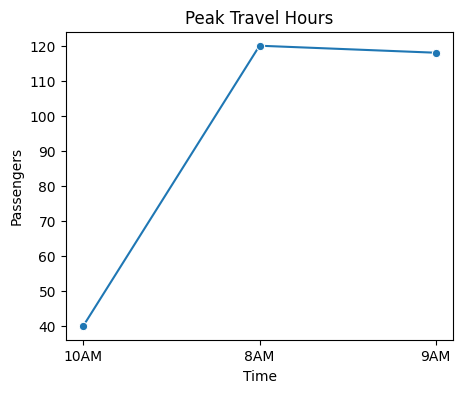

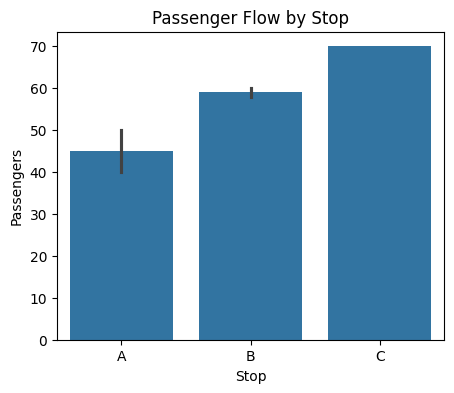

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    "Route": ["R1", "R2", "R1", "R3", "R2", "R1"],
    "Stop": ["A", "B", "C", "A", "B", "C"],
    "Time": ["8AM", "9AM", "8AM", "10AM", "9AM", "8AM"],
    "Passengers": [50, None, 70, 40, 60, 70]
}

df = pd.DataFrame(data)

print("Original Data")
print(df)

df["Passengers"] = df["Passengers"].fillna(df["Passengers"].mean())
df = df.drop_duplicates()
df = df[df["Route"].str.startswith("R")]

route = df.groupby("Route")["Passengers"].sum().reset_index()
time = df.groupby("Time")["Passengers"].sum().reset_index()

print("\nPassengers by Route")
print(route)

print("\nPassengers by Time")
print(time)

plt.figure(figsize=(5,4))
sns.barplot(x="Route", y="Passengers", data=route)
plt.title("Busiest Routes")
plt.show()

plt.figure(figsize=(5,4))
sns.lineplot(x="Time", y="Passengers", data=time, marker="o")
plt.title("Peak Travel Hours")
plt.show()

plt.figure(figsize=(5,4))
sns.barplot(x="Stop", y="Passengers", data=df)
plt.title("Passenger Flow by Stop")
plt.show()